In [1]:
# Cell 1: Import all required libraries
import pyspark
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("PySpark version:", pyspark.__version__)
print("Pandas version:", pd.__version__)
print("✅ All libraries imported successfully")

PySpark version: 4.1.1
Pandas version: 3.0.3
✅ All libraries imported successfully


In [2]:
# Cell 2: Create Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FraudDetection_Group08") \
    .config("spark.sql.shuffle.partitions", "4") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark Version: {spark.version}")
print(f"✅ Spark is running on all CPU cores (local[*])")
print(f"✅ Spark UI available at: http://localhost:4040")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/16 23:18:00 WARN Utils: Your hostname, pc, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/05/16 23:18:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/16 23:18:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark Version: 4.1.1
✅ Spark is running on all CPU cores (local[*])
✅ Spark UI available at: http://localhost:4040


In [3]:
# Cell 3: Load the dataset
df = spark.read.csv(
    "creditcard.csv",
    header=True,
    inferSchema=True
)

print(f"✅ Dataset loaded successfully")
print(f"📊 Total records: {df.count():,}")
print(f"📋 Total columns: {len(df.columns)}")
print(f"\n=== COLUMN NAMES ===")
print(df.columns)

✅ Dataset loaded successfully
📊 Total records: 284,807
📋 Total columns: 31

=== COLUMN NAMES ===
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [4]:
# Cell 4: Explore the dataset
print("=== FIRST 5 ROWS ===")
df.show(5, truncate=True)

print("=== BASIC STATISTICS ===")
df.select("Amount", "Time", "Class").describe().show()

=== FIRST 5 ROWS ===
+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|               V19|                V20|                 V21|    

[Stage 6:>                                                          (0 + 6) / 6]

+-------+------------------+-----------------+--------------------+
|summary|            Amount|             Time|               Class|
+-------+------------------+-----------------+--------------------+
|  count|            284807|           284807|              284807|
|   mean| 88.34961925094233|94813.85957508067|0.001727485630620034|
| stddev|250.12010924018833|47488.14595456595| 0.04152718963546499|
|    min|               0.0|              0.0|                   0|
|    max|          25691.16|         172792.0|                   1|
+-------+------------------+-----------------+--------------------+



=== CLASS DISTRIBUTION ===


+-----+------+
|Class| count|
+-----+------+
|    0|284315|
|    1|   492|
+-----+------+

   Class   count  percentage
0      0  284315     99.8273
1      1     492      0.1727


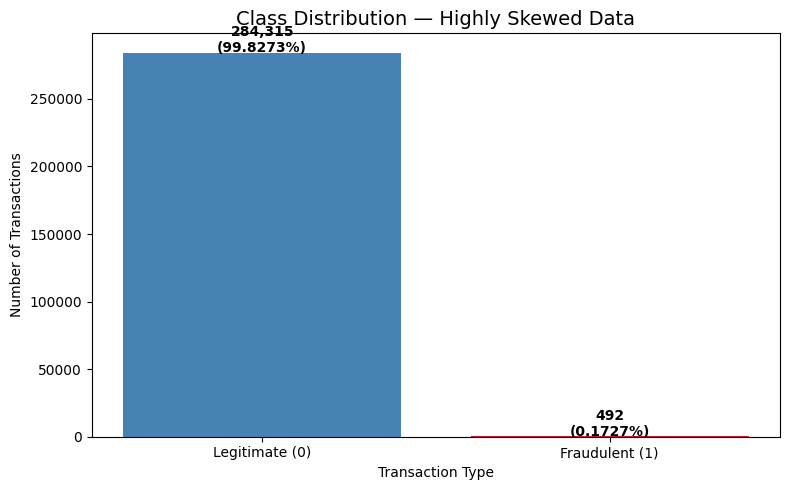

✅ Chart saved to output/class_distribution.png


In [5]:
# Cell 5: Check class imbalance (Skewed Data Analysis)
print("=== CLASS DISTRIBUTION ===")
class_dist = df.groupBy("Class").count().orderBy("Class")
class_dist.show()

# Convert to pandas for visualization
class_pd = class_dist.toPandas()
total = class_pd["count"].sum()
class_pd["percentage"] = (class_pd["count"] / total * 100).round(4)
print(class_pd)

# Visualize
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(["Legitimate (0)", "Fraudulent (1)"],
        class_pd["count"],
        color=["steelblue", "crimson"])
plt.title("Class Distribution — Highly Skewed Data", fontsize=14)
plt.ylabel("Number of Transactions")
plt.xlabel("Transaction Type")
for i, v in enumerate(class_pd["count"]):
    plt.text(i, v + 100,
             f'{v:,}\n({class_pd["percentage"].iloc[i]}%)',
             ha='center', fontweight='bold')
plt.tight_layout()

# Save output
import os
os.makedirs("output", exist_ok=True)
plt.savefig("output/class_distribution.png", dpi=150)
plt.show()
print("✅ Chart saved to output/class_distribution.png")

In [6]:
# Cell 6: Rule-Based Parallel Fraud Detection
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

df_flagged = df.withColumn(
    "risk_score",
    (
        # Rule 1: High transaction amount (> 1000)
        (F.col("Amount") > 1000).cast(IntegerType()) * 2 +

        # Rule 2: Very high amount (> 5000)
        (F.col("Amount") > 5000).cast(IntegerType()) * 3 +

        # Rule 3: Unusual time (late night: < 3600 or > 75000 seconds)
        (
            (F.col("Time") < 3600) | (F.col("Time") > 75000)
        ).cast(IntegerType()) * 1 +

        # Rule 4: Extreme V1 value (known fraud indicator)
        (F.col("V1") < -3).cast(IntegerType()) * 2 +

        # Rule 5: Extreme V3 value
        (F.col("V3") < -3).cast(IntegerType()) * 2 +

        # Rule 6: Combined suspicious pattern
        (
            (F.col("Amount") > 200) & (F.col("V14") < -5)
        ).cast(IntegerType()) * 3
    )
).withColumn(
    "flagged_as_fraud",
    (F.col("risk_score") >= 3).cast(IntegerType())
)

print("✅ Risk scoring applied in parallel across all partitions")
print("\n=== FLAGGING RESULTS ===")
df_flagged.groupBy("flagged_as_fraud").count().show()
print("\n=== SAMPLE FLAGGED TRANSACTIONS ===")
df_flagged.filter(F.col("flagged_as_fraud") == 1) \
    .select("Time", "Amount", "V1", "V3", "V14", "risk_score", "Class") \
    .show(10)

✅ Risk scoring applied in parallel across all partitions

=== FLAGGING RESULTS ===


+----------------+------+
|flagged_as_fraud| count|
+----------------+------+
|               0|271693|
|               1| 13114|
+----------------+------+


=== SAMPLE FLAGGED TRANSACTIONS ===
+----+-------+------------------+-------------------+------------------+----------+-----+
|Time| Amount|                V1|                 V3|               V14|risk_score|Class|
+----+-------+------------------+-------------------+------------------+----------+-----+
|14.0|   46.8| -5.40125766315825|   1.18630463143652|-0.479129929276704|         3|    0|
|36.0|1402.95| -1.00492933857661|-0.0380388289597724|-0.341956368039262|         3|    0|
|52.0|   1.46| -3.00523672241459|   1.48369073726212| -2.83713599830894|         3|    0|
|55.0| 200.01| -4.57509260816239|   3.40258500379828| -1.24682940571382|         3|    0|
|59.0|1142.02|-0.773292609110981| -0.932037567076045|-0.259878797128783|         3|    0|
|80.0|  39.95| -3.00773905109524| -0.423720855498033| 0.328058800506629|         3|   

In [7]:
# Cell 7: Evaluate Detection Accuracy
from pyspark.sql.functions import when

df_eval = df_flagged.withColumn(
    "result",
    when((F.col("Class") == 1) & (F.col("flagged_as_fraud") == 1), "True Positive")
    .when((F.col("Class") == 0) & (F.col("flagged_as_fraud") == 0), "True Negative")
    .when((F.col("Class") == 0) & (F.col("flagged_as_fraud") == 1), "False Positive")
    .when((F.col("Class") == 1) & (F.col("flagged_as_fraud") == 0), "False Negative")
)

results = df_eval.groupBy("result").count().toPandas()
print("=== DETECTION EVALUATION ===")
print(results)

# Calculate metrics
tp = results[results["result"] == "True Positive"]["count"].values[0] if "True Positive" in results["result"].values else 0
fp = results[results["result"] == "False Positive"]["count"].values[0] if "False Positive" in results["result"].values else 0
fn = results[results["result"] == "False Negative"]["count"].values[0] if "False Negative" in results["result"].values else 0

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📊 True Positives  (Fraud correctly caught): {tp}")
print(f"📊 False Positives (Legit wrongly flagged):  {fp}")
print(f"📊 False Negatives (Fraud missed):           {fn}")
print(f"\n📊 Precision: {precision:.4f}")
print(f"📊 Recall:    {recall:.4f}")
print(f"📊 F1 Score:  {f1:.4f}")

[Stage 24:>                                                         (0 + 6) / 6]

=== DETECTION EVALUATION ===
           result   count
0  False Negative     182
1   True Positive     310
2   True Negative  271511
3  False Positive   12804

📊 True Positives  (Fraud correctly caught): 310
📊 False Positives (Legit wrongly flagged):  12804
📊 False Negatives (Fraud missed):           182

📊 Precision: 0.0236
📊 Recall:    0.6301
📊 F1 Score:  0.0456


In [8]:
# Cell 8: Save high-risk transactions to output folder
high_risk = df_flagged.filter(F.col("flagged_as_fraud") == 1) \
    .select("Time", "Amount", "V1", "V3", "V14", 
            "risk_score", "flagged_as_fraud", "Class") \
    .orderBy(F.col("risk_score").desc())

print(f"🚨 Total flagged transactions: {high_risk.count():,}")
print("\nTop 10 highest-risk transactions:")
high_risk.show(10)

# Save to CSV
high_risk.coalesce(1).write.csv(
    "output/flagged_transactions", 
    header=True, 
    mode="overwrite"
)
print("✅ Saved to output/flagged_transactions/")

🚨 Total flagged transactions: 13,114

Top 10 highest-risk transactions:


+--------+--------+-----------------+-----------------+------------------+----------+----------------+-----+
|    Time|  Amount|               V1|               V3|               V14|risk_score|flagged_as_fraud|Class|
+--------+--------+-----------------+-----------------+------------------+----------+----------------+-----+
|166198.0|25691.16|-35.5485392112513|-48.3255893623954| -6.79594155719079|        13|               1|    0|
| 95286.0| 18910.0|-34.5492960902358|-21.3408541341773|  5.98921033200754|        10|               1|    0|
|  1264.0| 7712.43|-11.1407063576909|-12.3895452301042| -1.65283565614104|        10|               1|    0|
|101160.0| 5707.82|-8.97351456835346|-7.01971022865962|   2.5199712925726|        10|               1|    0|
|152763.0|  8787.0|-14.6417095163303|-12.7144615882512|  2.67785660067222|        10|               1|    0|
|111347.0| 5420.61|-8.57246360678349|-7.01181779062616|  2.66517819052216|        10|               1|    0|
|133971.0| 7583.32|

In [9]:
# Cell 9: Cross-Group Portability Test
# Any group can call this function with their own transaction values

from pyspark.sql.types import StructType, StructField, FloatType, IntegerType

def test_transaction(time_val, amount, v1, v3, v14):
    """
    CROSS-GROUP PORTABILITY TEST
    ============================
    Pass any transaction through the fraud detection pipeline.
    
    Parameters:
    - time_val : seconds since first transaction (0 to 172792)
    - amount   : transaction amount in USD
    - v1       : PCA feature 1 (normal range: -3 to 3)
    - v3       : PCA feature 3 (normal range: -3 to 3)
    - v14      : PCA feature 14 (normal range: -3 to 3)
    """
    schema = StructType([
        StructField("Time",   FloatType(),   True),
        StructField("V1",     FloatType(),   True),
        StructField("V3",     FloatType(),   True),
        StructField("V14",    FloatType(),   True),
        StructField("Amount", FloatType(),   True),
        StructField("Class",  IntegerType(), True),
    ])

    test_data = [(float(time_val), float(v1), float(v3),
                  float(v14), float(amount), -1)]

    test_df = spark.createDataFrame(test_data, schema)

    result = test_df.withColumn(
        "risk_score",
        (
            (F.col("Amount") > 1000).cast(IntegerType()) * 2 +
            (F.col("Amount") > 5000).cast(IntegerType()) * 3 +
            ((F.col("Time") < 3600) | (F.col("Time") > 75000)).cast(IntegerType()) * 1 +
            (F.col("V1") < -3).cast(IntegerType()) * 2 +
            (F.col("V3") < -3).cast(IntegerType()) * 2 +
            ((F.col("Amount") > 200) & (F.col("V14") < -5)).cast(IntegerType()) * 3
        )
    ).withColumn(
        "flagged_as_fraud",
        (F.col("risk_score") >= 3).cast(IntegerType())
    )

    row = result.collect()[0]

    print("=" * 45)
    print("   🧪 CROSS-GROUP PORTABILITY TEST")
    print("=" * 45)
    print(f"  Time:    {time_val} seconds")
    print(f"  Amount:  ${amount:.2f}")
    print(f"  V1:      {v1}")
    print(f"  V3:      {v3}")
    print(f"  V14:     {v14}")
    print("-" * 45)
    print(f"  Risk Score:  {row['risk_score']}")
    if row['flagged_as_fraud'] == 1:
        print(f"  Decision: 🚨 FRAUDULENT — Transaction BLOCKED")
    else:
        print(f"  Decision: ✅ LEGITIMATE — Transaction APPROVED")
    print("=" * 45)


# ── TEST CASE 1: Normal transaction ──
print("\n📋 TEST CASE 1: Small normal transaction")
test_transaction(time_val=50000, amount=25.50, v1=0.5, v3=0.2, v14=0.1)

# ── TEST CASE 2: High amount + suspicious features ──
print("\n📋 TEST CASE 2: High amount with suspicious features")
test_transaction(time_val=1000, amount=6000, v1=-4.5, v3=-3.8, v14=-6.2)

# ── TEST CASE 3: Late night suspicious transaction ──
print("\n📋 TEST CASE 3: Late night + suspicious pattern")
test_transaction(time_val=500, amount=350, v1=-1.2, v3=-0.5, v14=-5.5)


📋 TEST CASE 1: Small normal transaction


   🧪 CROSS-GROUP PORTABILITY TEST
  Time:    50000 seconds
  Amount:  $25.50
  V1:      0.5
  V3:      0.2
  V14:     0.1
---------------------------------------------
  Risk Score:  0
  Decision: ✅ LEGITIMATE — Transaction APPROVED

📋 TEST CASE 2: High amount with suspicious features
   🧪 CROSS-GROUP PORTABILITY TEST
  Time:    1000 seconds
  Amount:  $6000.00
  V1:      -4.5
  V3:      -3.8
  V14:     -6.2
---------------------------------------------
  Risk Score:  13
  Decision: 🚨 FRAUDULENT — Transaction BLOCKED

📋 TEST CASE 3: Late night + suspicious pattern
   🧪 CROSS-GROUP PORTABILITY TEST
  Time:    500 seconds
  Amount:  $350.00
  V1:      -1.2
  V3:      -0.5
  V14:     -5.5
---------------------------------------------
  Risk Score:  4
  Decision: 🚨 FRAUDULENT — Transaction BLOCKED


In [10]:
# Cell 10: Stop Spark Session
spark.stop()
print("✅ Spark session stopped cleanly.")
print("✅ Project complete — Group 08: Fraudulent Transaction Detection")

✅ Spark session stopped cleanly.
✅ Project complete — Group 08: Fraudulent Transaction Detection
